# Model comparison — overview & scorecard

Entry point for **decision making**: effort, pipeline outcomes and a cross-dimension KPI scorecard comparing the models on one screen. Detailed evidence lives in `10_build`, `20_tests_coverage` and `30_code_metrics`. Iterations are independent samples; only iterations 1–6 are included.

In [1]:
STORY_ID = "CPD-LC-001-001"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import tdd_results as tdd

tdd.setup_theme()
data = tdd.load_all(STORY_ID)
MODELS = tdd.discover_models(STORY_ID)
PAL = tdd.model_palette(MODELS)        # fixed model -> color, used everywhere
HUE = list(PAL)                        # fixed hue_order, used everywhere

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
print(f"story: {STORY_ID} | models: {MODELS}")
print("palette:", PAL)
if tdd.load_warnings:
    print(f"{len(tdd.load_warnings)} load warnings -> tdd.load_warnings")

story: CPD-LC-001-001 | models: ['DeepSeek-V4-Pro', 'Kimi-K2.5', 'grok-4.3']
palette: {'DeepSeek-V4-Pro': '#2a78d6', 'Kimi-K2.5': '#1baf7a', 'grok-4.3': '#eda100'}


## Iteration summary (master table)

One row per (model, iteration): final build/test/coverage/metrics outcomes,
pipeline stage statuses and attempt counts. `NaN` = the stage produced no
canonical result for that cell. This table backs every chart below.

In [3]:
summ = tdd.iteration_summary(STORY_ID, data)
display(summ.round(3))

,story,model,iteration,build_status,build_errors,build_warnings,test_status,total_tests,passed,failed,skipped,pass_rate,line_rate,branch_rate,median_mi,min_mi,max_cc,max_coupling,max_dit,n_types,pct_green_types,source_lines,executable_lines,tg_status,tg_test_methods,cg_status,cg_files_created,cg_files_modified,ref_status,ref_all_green,ref_loop_iterations,ref_n_remaining_violations,build_attempts,test_attempts,metrics_attempts
0,CPD-LC-001-001,DeepSeek-V4-Pro,1,success,0.0,0.0,success,24,24,0,0,1.000,0.582,0.800,71.0,54,5,15,1,27,0.926,655,90,success,21.0,success,10.0,5.0,partial,False,6.0,1,15.0,14,7
1,CPD-LC-001-001,DeepSeek-V4-Pro,2,success,0.0,0.0,success,24,24,0,0,1.000,0.546,0.786,72.0,55,8,17,1,23,0.870,580,75,partial,21.0,success,9.0,6.0,partial,False,3.0,2,19.0,10,5
2,CPD-LC-001-001,DeepSeek-V4-Pro,3,success,0.0,0.0,success,21,21,0,0,1.000,0.654,0.800,72.5,54,6,21,1,24,0.917,576,73,NaN,NaN,partial,9.0,8.0,success,True,1.0,1,30.0,8,2
3,CPD-LC-001-001,DeepSeek-V4-Pro,4,success,0.0,0.0,success,24,24,0,0,1.000,0.593,0.800,71.0,55,4,15,1,25,0.920,573,69,partial,21.0,NaN,NaN,NaN,partial,False,4.0,1,20.0,13,6
4,CPD-LC-001-001,DeepSeek-V4-Pro,5,success,0.0,0.0,success,24,24,0,0,1.000,0.651,0.875,71.0,54,5,15,1,25,0.920,606,81,partial,17.0,success,10.0,7.0,partial,False,4.0,1,23.0,15,5
5,CPD-LC-001-001,DeepSeek-V4-Pro,6,failure,6.0,0.0,success,24,24,0,0,1.000,0.665,0.833,71.0,55,5,15,1,24,0.917,574,70,success,21.0,NaN,NaN,NaN,partial,False,3.0,1,15.0,11,5
6,CPD-LC-001-001,Kimi-K2.5,1,NaN,NaN,NaN,success,21,21,0,0,1.000,0.570,0.850,71.0,56,8,21,1,24,0.875,615,79,NaN,NaN,success,10.0,9.0,success,True,0.0,0,NaN,1,1
7,CPD-LC-001-001,Kimi-K2.5,2,success,0.0,0.0,success,24,24,0,0,1.000,0.551,0.857,71.0,56,5,19,1,25,0.920,576,72,success,21.0,success,10.0,12.0,success,True,1.0,0,12.0,5,3
8,CPD-LC-001-001,Kimi-K2.5,3,success,0.0,0.0,success,24,24,0,0,1.000,0.587,0.923,71.0,55,8,15,1,25,0.960,576,73,NaN,NaN,success,10.0,9.0,success,True,5.0,0,18.0,11,7
9,CPD-LC-001-001,Kimi-K2.5,4,success,0.0,2.0,success,24,24,0,0,1.000,0.547,0.750,74.0,55,5,15,1,27,0.963,606,77,NaN,NaN,success,10.0,11.0,success,True,4.0,0,18.0,7,5


## Effort: executions per iteration

Every retry the agent needed before moving on, per result tree. Taller bars =
more friction. Compare models at the same iteration position.

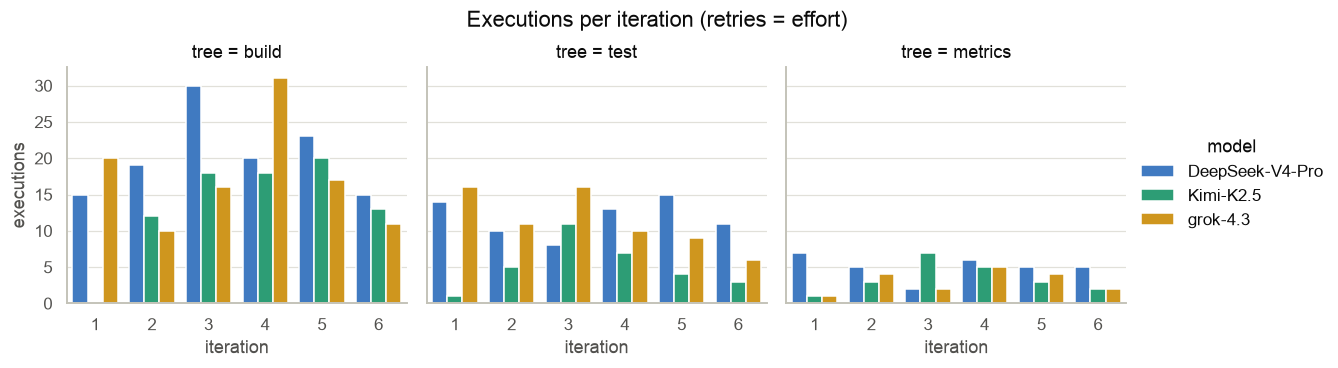

In [4]:
ac = pd.concat([
    tdd.attempt_counts(data["build"], "build"),
    tdd.attempt_counts(data["test"], "test"),
    tdd.attempt_counts(data["metrics_types"], "metrics"),
])
if ac.empty:
    print("No data for this section.")
else:
    g = sns.catplot(data=ac, kind="bar", x="iteration", y="n_attempts",
                    hue="model", col="tree", hue_order=HUE, palette=PAL,
                    height=3.2, aspect=1.1)
    g.set_axis_labels("iteration", "executions")
    g.figure.suptitle("Executions per iteration (retries = effort)", y=1.04)

## Effort distribution per model

Small samples (6 iterations/model), so every point is shown over the box.
A tight low box = the model converges with little friction.

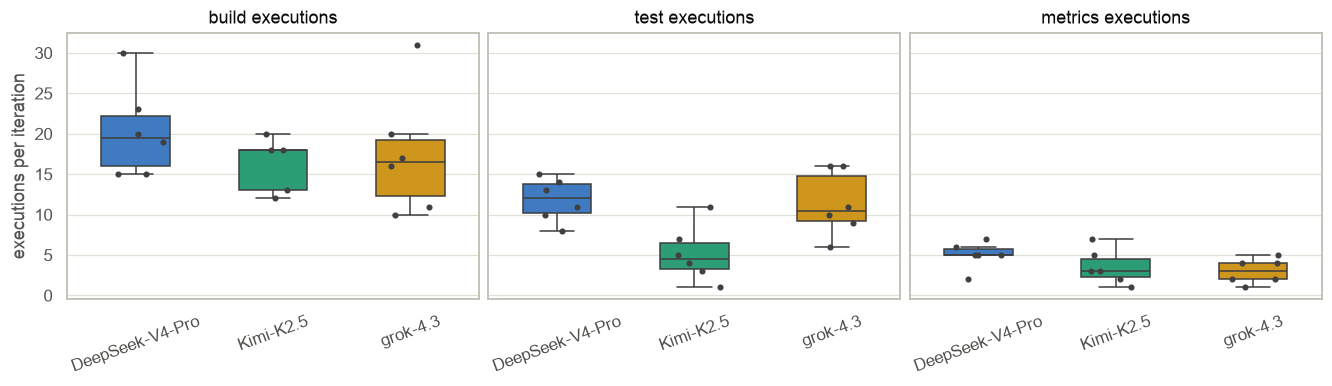

In [5]:
if ac.empty:
    print("No data for this section.")
else:
    trees = list(ac["tree"].unique())
    fig, axes = plt.subplots(1, len(trees), figsize=(4 * len(trees), 3.4), sharey=True)
    for ax, tree in zip(np.atleast_1d(axes), trees):
        sub = ac[ac["tree"] == tree]
        sns.boxplot(data=sub, x="model", y="n_attempts", hue="model", order=HUE,
                    hue_order=HUE, palette=PAL, legend=False, width=0.5,
                    showfliers=False, ax=ax)
        sns.stripplot(data=sub, x="model", y="n_attempts", order=HUE,
                      color=".25", size=4, jitter=0.2, ax=ax)
        ax.set_title(f"{tree} executions")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=20)
    axes_flat = np.atleast_1d(axes)
    axes_flat[0].set_ylabel("executions per iteration")

## Pipeline stage outcomes per cell

One matrix per stage; each cell is (model, iteration). `S` = success,
`P` = partial, `F` = failure; gray = no result recorded.

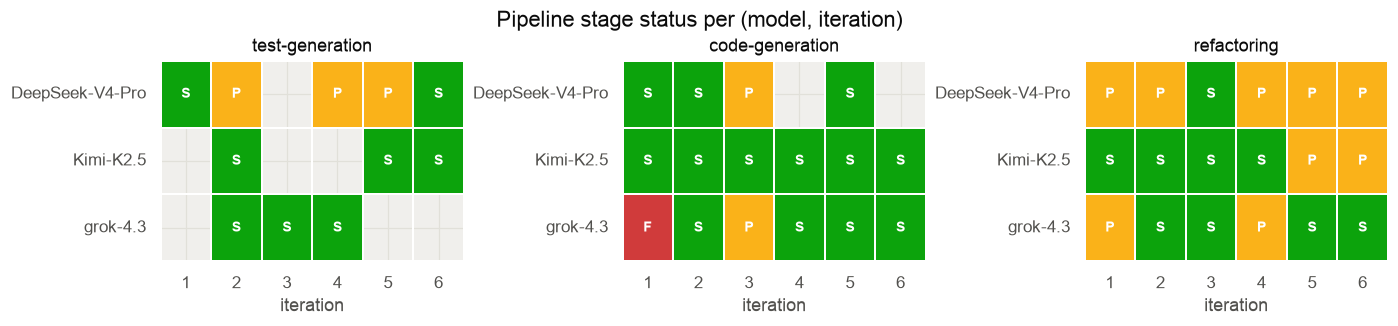

In [6]:
from matplotlib.colors import BoundaryNorm, ListedColormap

stages = data["stages"]
if stages.empty:
    print("No data for this section.")
else:
    order = ["test-generation", "code-generation", "refactoring"]
    code_map = {"failure": 0, "partial": 1, "success": 2}
    abbr = {"failure": "F", "partial": "P", "success": "S"}
    iters = sorted(stages["iteration"].unique())
    cmap = ListedColormap([tdd.STAGE_STATUS_COLORS["failure"],
                           tdd.STAGE_STATUS_COLORS["partial"],
                           tdd.STAGE_STATUS_COLORS["success"]])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)
    fig, axes = plt.subplots(1, len(order), figsize=(4.2 * len(order), 2.6))
    for ax, stage in zip(np.atleast_1d(axes), order):
        sub = stages[stages["stage"] == stage]
        grid = (sub.pivot(index="model", columns="iteration", values="status")
                   .reindex(index=HUE, columns=iters))
        sns.heatmap(grid.map(code_map.get), cmap=cmap, norm=norm, cbar=False,
                    annot=grid.map(lambda s: abbr.get(s, "")), fmt="",
                    linewidths=1, linecolor="white", ax=ax,
                    annot_kws={"fontsize": 9, "color": "white", "fontweight": "bold"})
        ax.set_facecolor("#f0efec")
        ax.set_title(stage)
        ax.set_ylabel("")
    fig.suptitle("Pipeline stage status per (model, iteration)", y=1.08)

## Refactoring: all-green achievement and loop cost

Left: how often the refactoring loop drove every metric flag to GREEN
(annotated with the raw fraction — n is small). Right: how many loop
iterations it took; points on the dashed line hit the budget ceiling.

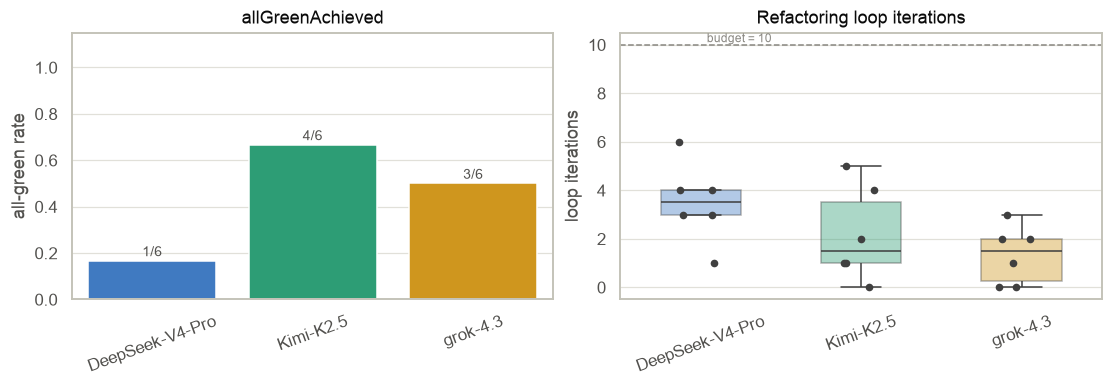

In [7]:
ref = data["stages"].query("stage == 'refactoring'") if not data["stages"].empty else data["stages"]
if ref.empty:
    print("No refactoring results.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))

    ag = (ref.assign(all_green=ref["ref_all_green"].map({True: 1.0, False: 0.0}))
             .groupby("model")["all_green"].agg(rate="mean", achieved="sum", n="count")
             .reindex(HUE))
    sns.barplot(x=ag.index, y=ag["rate"], hue=ag.index, hue_order=HUE,
                palette=PAL, legend=False, ax=ax1)
    for i, (_, row) in enumerate(ag.iterrows()):
        ax1.text(i, row["rate"] + 0.02, f"{int(row['achieved'])}/{int(row['n'])}",
                 ha="center", fontsize=9, color=tdd.INK["secondary"])
    ax1.set_ylim(0, 1.15)
    ax1.set_ylabel("all-green rate")
    ax1.set_xlabel("")
    ax1.set_title("allGreenAchieved")
    ax1.tick_params(axis="x", rotation=20)

    sns.boxplot(data=ref, x="model", y="ref_loop_iterations", hue="model",
                order=HUE, hue_order=HUE, palette=PAL, legend=False,
                width=0.5, showfliers=False, boxprops={"alpha": 0.4}, ax=ax2)
    sns.stripplot(data=ref, x="model", y="ref_loop_iterations", order=HUE,
                  color=".25", size=5, jitter=0.15, ax=ax2)
    ceiling = ref["ref_max_loop_iterations"].max()
    if pd.notna(ceiling):
        ax2.axhline(ceiling, ls="--", color=tdd.INK["muted"], lw=1)
        ax2.text(0.02, ceiling, f" budget = {int(ceiling)}", va="bottom",
                 fontsize=8, color=tdd.INK["muted"])
    ax2.set_ylabel("loop iterations")
    ax2.set_xlabel("")
    ax2.set_title("Refactoring loop iterations")
    ax2.tick_params(axis="x", rotation=20)

## KPI scorecard

All dimensions on one screen. Color = per-column min-max normalization,
oriented so **darker = better** (columns marked ↓ are inverted: lower raw
value is better). Numbers are the **raw** values — read those for decisions;
color only ranks the three models per column.

,build success rate,build attempts ↓,test pass rate,tests emitted / intent,line coverage,branch coverage,median MI,% all-GREEN types,all-green rate,refactor loops ↓
model,,,,,,,,,,
DeepSeek-V4-Pro,0.833,20.333,1.000,0.962,0.615,0.816,71.00,0.911,0.167,3.500
Kimi-K2.5,1.000,16.200,1.000,1.000,0.557,0.847,71.75,0.923,0.667,2.167
grok-4.3,0.833,17.500,0.979,1.000,0.567,0.836,72.50,0.897,0.500,1.333


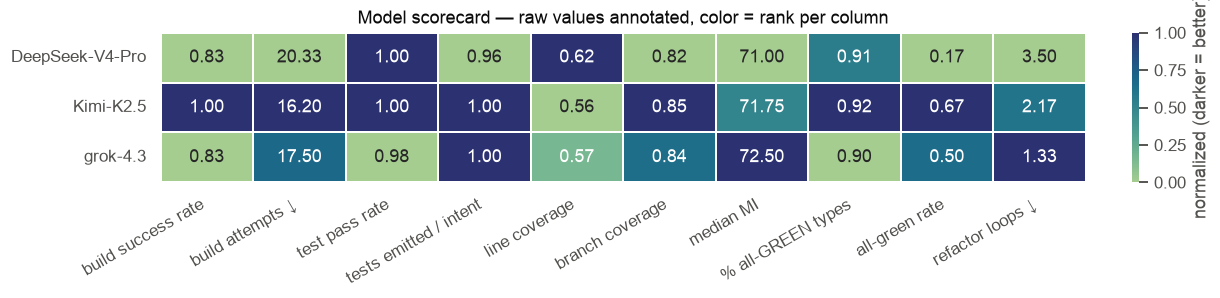

In [8]:
intents_total = data["intents"]["n_intents"].sum() if not data["intents"].empty else np.nan
by_model = summ.groupby("model")
kpis = pd.DataFrame({
    "build success rate": by_model["build_status"].agg(lambda s: s.dropna().eq("success").mean()),
    "build attempts ↓": by_model["build_attempts"].mean(),
    "test pass rate": by_model["pass_rate"].mean(),
    "tests emitted / intent": by_model["tg_test_methods"].mean() / intents_total,
    "line coverage": by_model["line_rate"].mean(),
    "branch coverage": by_model["branch_rate"].mean(),
    "median MI": by_model["median_mi"].median(),
    "% all-GREEN types": by_model["pct_green_types"].mean(),
    "all-green rate": by_model["ref_all_green"].agg(
        lambda s: s.map({True: 1.0, False: 0.0}).mean()),
    "refactor loops ↓": by_model["ref_loop_iterations"].mean(),
}).reindex(HUE)

norm = kpis.copy()
for col in norm:
    v = norm[col].astype(float)
    lo, hi = v.min(), v.max()
    n = (v - lo) / (hi - lo) if hi > lo else pd.Series(0.5, index=v.index)
    norm[col] = 1 - n if col.endswith("↓") else n

annot = kpis.map(lambda v: "n/a" if pd.isna(v) else f"{v:.2f}")
fig, ax = plt.subplots(figsize=(11, 2.6))
sns.heatmap(norm.astype(float), annot=annot, fmt="", cmap="crest",
            vmin=0, vmax=1, linewidths=1, linecolor="white",
            cbar_kws={"label": "normalized (darker = better)"}, ax=ax)
ax.set_facecolor("#f0efec")
ax.set_ylabel("")
ax.set_title("Model scorecard — raw values annotated, color = rank per column")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
display(kpis.round(3))

## Sanity checks

In [9]:
fb = tdd.finals(data["build"])
if not fb.empty:
    assert fb.groupby(["story", "model", "iteration"]).size().max() == 1
    assert fb["ts"].notna().all()
if not data["coverage"].empty:
    assert data["coverage"]["line_rate"].between(0, 1).all()
assert summ["iteration"].max() <= 6, "iterations beyond 6 must be excluded"
print(f"sanity checks passed | {len(tdd.load_warnings)} load warnings")

sanity checks passed | 0 load warnings
